# Background — Time-Series Basics (อ่านก่อนเข้าโมดูล time series)
#
โน้ตบุ๊กนี้รวบพื้นฐานที่โมดูล time series จะใช้ — เจาะจงเฉพาะสิ่งที่ทำให้ "ข้อมูลอนุกรมเวลา" ต่างจากตารางข้อมูลทั่วไป และเครื่องมือคิดพื้นฐาน 4 ชิ้น: **การแยกองค์ประกอบ** (trend / seasonality / noise), **autocorrelation**, **การแบ่ง train/test ตามเวลา** และ **baseline แบบ naive** ที่ใช้เป็นไม้บรรทัดวัดทุกโมเดลจริง
#
**สิ่งที่ต้องรู้ก่อน:** จาก Day 1–2 — distribution, linear regression, cross-validation แบบ k-fold (จาก Module 5) พอแล้ว

## 1. ข้อมูลอนุกรมเวลาต่างจากตารางข้อมูลอย่างไร
#
ทุกโมดูลก่อนหน้านี้เราเจอข้อมูลแบบ **i.i.d.** — แถวไหนมาก่อนมาหลังไม่สำคัญ สลับแถวแล้วผลการเทรนไม่เปลี่ยน แต่ข้อมูลอนุกรมเวลา (time series) คือการวัดค่าเดิม **ซ้ำตามเวลา** ลำดับคือข้อมูลสำคัญที่สุด:
#
- ค่าวันนี้ **ไม่เป็นอิสระ** จากค่าเมื่อวาน — การอ่านค่ามาตรฐานที่ลื่นไถล (drift) มี "ความจำ"
- การสลับแถวทำลายข้อมูลทันที — โมเดลที่เรียนจากอนาคตไปอดีต (leakage) จะดูเก่งเท็จ
- คำถามหลักของโมดูลนี้ไม่ใช่ "ค่า x ทำนาย y อย่างไร" แต่เป็น "**ค่าในอดีตทำนายค่าถัดไปอย่างไร**"

In [1]:
import numpy as np

rng = np.random.default_rng(42)

n = 240  # 240 เดือน = 20 ปี
t = np.arange(n)
trend = 100.0 + 0.05 * t  # drift ช้า ๆ
season = 2.0 * np.sin(2 * np.pi * t / 12)  # ฤดูกาลรอบ 12 จุด
noise = rng.normal(0, 0.4, n)
y = trend + season + noise

print("มูลค่า 5 จุดแรก:", np.round(y[:5], 2))
print("ค่าเฉลี่ย 20 จุดแรก:", round(float(y[:20].mean()), 2))
print("ค่าเฉลี่ย 20 จุดหลัง:", round(float(y[-20:].mean()), 2))

มูลค่า 5 จุดแรก: [100.12 100.63 102.13 102.53 101.15]
ค่าเฉลี่ย 20 จุดแรก: 100.79
ค่าเฉลี่ย 20 จุดหลัง: 111.18


สังเกต: ค่าเฉลี่ยช่วงต้นกับช่วงท้าย **ต่างกันมาก** — ในข้อมูล i.i.d. เราเรียกสิ่งนี้ว่า distribution shift ที่น่ากลัว แต่ในอนุกรมเวลามันคือ **trend** ซึ่งเป็นสัญญาณที่เราอยากเรียนรู้ ไม่ใช่ปัญหาที่ต้องกำจัด

## 2. การแยกองค์ประกอบด้วยมือ — trend + seasonality + noise
#
โมเดลคลาสสิกของอนุกรมเวลาเขียนได้ว่า
#
$$y_t = T_t + S_t + \varepsilon_t$$
#
- **T** — แนวโน้มระยะยาว (ในโลกเมโทรโลยี = **drift ของมาตรฐานอ้างอิง**)
- **S** — ฤดูกาล คือแบบแผนที่ทำซ้ำด้วยคาบคงที่ (อุณหภูมิห้องแล็บตามฤดู, ปริมาณงานตามรอบเดือน)
- **ε** — noise เศษเหลือที่อธิบายไม่ได้
#
เราจะแยกทั้งสามด้วยมือ — ไม่ต้องใช้ไลบรารีพิเศษ:

ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)

trend: rolling mean แบบ centered หน้าต่าง = 1 คาบฤดูกาล (12) — ฤดูกาลหักล้างกันเองในหน้าต่าง

seasonal: ค่าเฉลี่ยของ (y - trend) แยกตามตำแหน่งในคาบ

In [2]:
import matplotlib.pyplot as plt  # noqa: E402

plt.rcParams["font.family"] = [
    "DejaVu Sans",
    "Noto Sans Thai",
    "Leelawadee UI",
    "Tahoma",
    "Thonburi",
]

half = 6
trend_est = np.array([y[max(0, i - half) : i + half].mean() for i in range(n)])

detrended = y - trend_est
phase = t % 12
seasonal_profile = np.array([detrended[phase == p].mean() for p in range(12)])
seasonal_est = seasonal_profile[phase]

residual = y - trend_est - seasonal_est

print("seasonal profile (จุดที่ 0..11 ของคาบ):", np.round(seasonal_profile, 2))
print(
    "residual std:", round(float(residual.std()), 3), " (เทียบ noise σ = 0.4)"
)

seasonal profile (จุดที่ 0..11 ของคาบ): [-0.16  0.98  1.62  2.    1.74  1.06  0.19 -1.08 -1.74 -1.98 -1.62 -0.83]
residual std: 0.367  (เทียบ noise σ = 0.4)


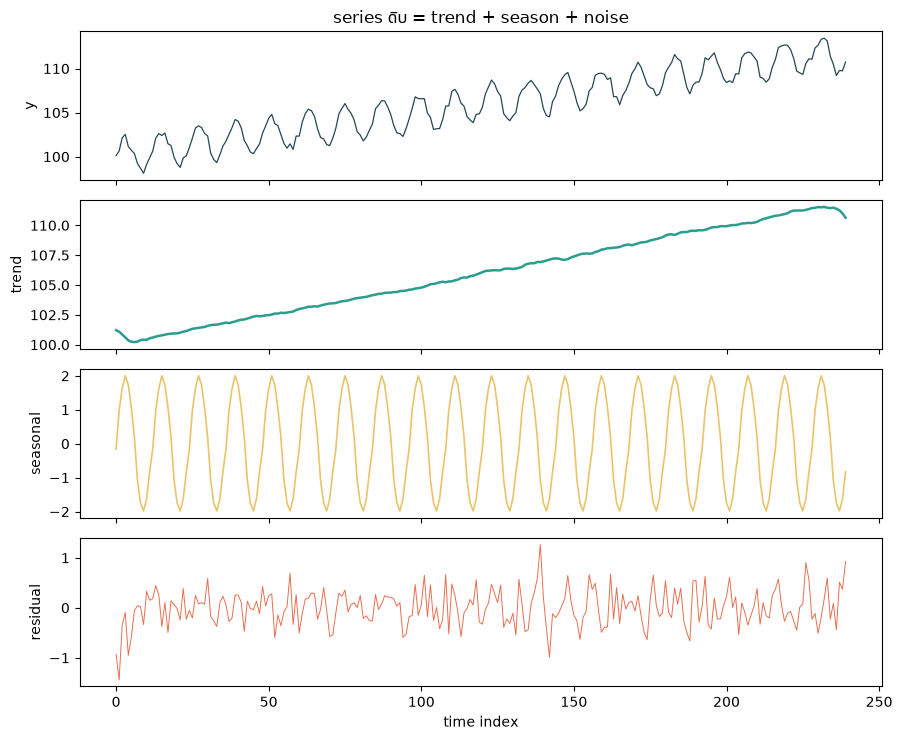

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(9, 7.5), sharex=True)
axes[0].plot(t, y, color="#264653", lw=0.9)
axes[0].set_ylabel("y")
axes[0].set_title("series ดิบ = trend + season + noise")
axes[1].plot(t, trend_est, color="#2a9d8f", lw=1.8)
axes[1].set_ylabel("trend")
axes[2].plot(t, seasonal_est, color="#e9c46a", lw=1.2)
axes[2].set_ylabel("seasonal")
axes[3].plot(t, residual, color="#e76f51", lw=0.7)
axes[3].set_ylabel("residual")
axes[3].set_xlabel("time index")
fig.tight_layout()
plt.show()

อ่านภาพ: แผงแรกคือของจริงที่ตาเห็น สามแผงที่เหลือคือการ "ถอดชิ้นส่วน" — trend ไต่สม่ำเสมอ (เหมือนมาตรฐานอ้างอิงที่ไหล), seasonal วนรอบ 12 จุดเป็นคลื่นสม่ำเสมอ, residual เหลือแค่ noise เล็ก ๆ ถ้า residual ยังมีแบบแผนเหลืออยู่ แปลว่าเราถอดไม่หมด — โมเดลยังมีอะไรให้เรียนเพิ่ม

## 3. Autocorrelation — "ความจำ" ของซีรีส์
#
Correlation วัดว่าสองตัวแปรเดินตามกันแค่ไหน **autocorrelation ที่ lag k** วัดว่าค่าที่เว้นระยะ k จุดเดินตามกันแค่ไหน:
#
$$\rho_k = \mathrm{corr}(y_t,\ y_{t-k})$$
#
- ρ₁ สูง → ค่าติดกันคล้ายกันมาก (ซีรีส์มีความจำสั้น) — ค่าวัดวันนี้ทำนายค่าพรุ่งนี้ได้ดี
- ρ₁₂ สูงในซีรีส์รายเดือน → แบบแผนฤดูกาลรายปี — ค่าเดือนนี้ปีกลายทำนายได้
- ρₖ ≈ 0 ทุก k → ซีรีส์ไม่มีความจำ = white noise โมเดลไหนก็ทำนายไม่ได้กว่าค่าเฉลี่ย

In [4]:
def autocorr(x: np.ndarray, k: int) -> float:
    """corr(x[t], x[t-k]) — ตัดคู่ที่ห้อยเกินขอบออก."""
    a, b = x[k:], x[:-k]
    return float(np.corrcoef(a, b)[0, 1])


for k in (1, 2, 3, 6, 12, 24):
    print(f"lag {k:>2}: ρ = {autocorr(y, k):+.3f}")

lag  1: ρ = +0.972
lag  2: ρ = +0.918
lag  3: ρ = +0.843
lag  6: ρ = +0.694
lag 12: ρ = +0.990
lag 24: ρ = +0.989


ρ₁ และ ρ₁₂ สูงเพราะ trend ทำให้ค่าที่ใกล้กัน (หรือห่างกันพอดีคาบ) อยู่ฝั่งเดียวกันของเส้นโค้ง สังเกตว่า lag 12 สูงเป็นพิเศษเพราะฤดูกาลซ้ำพอดีรอบ ลอง autocorrelate **residual** ดู — ควรจะเข้าใกล้ 0 ทุก lag:

In [5]:
print("autocorr ของ residual:")
for k in (1, 2, 12):
    print(f"lag {k:>2}: ρ = {autocorr(residual, k):+.3f}")

autocorr ของ residual:
lag  1: ρ = +0.191
lag  2: ρ = -0.009
lag 12: ρ = -0.059


หลักการสำคัญ: **หลังถอดองค์ประกอบที่รู้แล้ว residual ที่ดีคือ white noise** — ถ้ายังเหลือ autocorrelation สูง แปลว่ามีแบบแผนที่โมเดลยังจับไม่หมด (นี่คือเครื่องมือวินิจฉัยที่โมดูลหลักจะกลับมาใช้อีก)

## 4. แบ่ง train/test ตามเวลา — ห้ามสลับ
#
ใน Module 5 เราใช้ k-fold CV ที่สลับแถวก่อนแบ่ง กับอนุกรมเวลา **ห้ามทำ** — fold ที่ train มีข้อมูลอนาคตจะทำนายอดีตได้เก่งเท็จ (leakage แบบที่เจ็บที่สุดเพราะตัวเลขดูดีจริง ๆ)
#
ทางถูกคือตัดตามเวลา: train = อดีต, test = อนาคต แล้ว **เลื่อนหน้าต่าง** ไปเรื่อย ๆ (forward-chaining / `TimeSeriesSplit`):

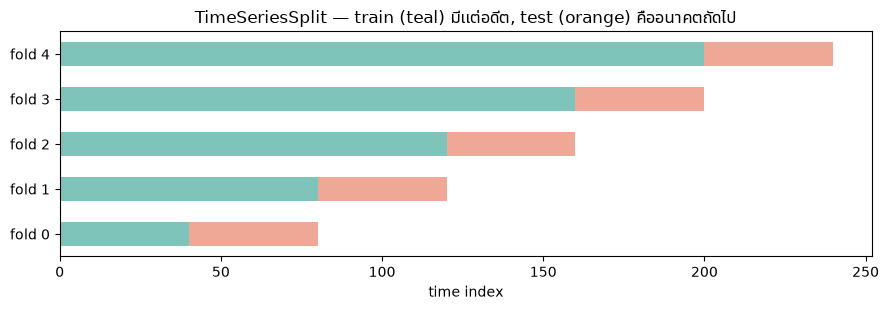

In [6]:
from sklearn.model_selection import TimeSeriesSplit  # noqa: E402

X_dummy = np.arange(n).reshape(-1, 1)  # ใช้แค่ดูรูปแบบ fold ไม่ได้เทรนจริง

tscv = TimeSeriesSplit(n_splits=5)
fig, ax = plt.subplots(figsize=(9, 3.2))
for i, (tr, te) in enumerate(tscv.split(X_dummy)):
    ax.barh(i, len(tr), left=0, height=0.55, color="#2a9d8f", alpha=0.6)
    ax.barh(
        i, len(te), left=tr[-1] + 1, height=0.55, color="#e76f51", alpha=0.6
    )
ax.set_yticks(range(5), [f"fold {i}" for i in range(5)])
ax.set_xlabel("time index")
ax.set_title(
    "TimeSeriesSplit — train (teal) มีแต่อดีต, test (orange) คืออนาคตถัดไป"
)
fig.tight_layout()
plt.show()

แต่ละ fold: train ยาวขึ้นเรื่อย ๆ test ต่อท้ายเสมอ — จำลองเงื่อนไขจริงที่ "โมเดลเก่าต้องทำนายค่าใหม่ที่ยังไม่เคยเห็น"

## 5. Baseline แบบ naive — ไม้บรรทัดก่อนใช้ ML
#
ก่อนสร้างโมเดลใด ๆ ให้วัดสองตัว naive ก่อนเสมอ:
#
- **persistence**: ทำนาย $y_t = y_{t-1}$ — "พรุ่งนี้เหมือนวันนี้"
- **seasonal naive**: ทำนาย $y_t = y_{t-12}$ — "เดือนนี้เหมือนเดือนเดียวกันปีกลาย"
#
โมเดล ML ที่แพ้ baseline ตัวใดตัวหนึ่ง **ยังไม่มีค่า** — มันต้องจ่ายความซับซ้อนให้เห็นผลเกิน naive เท่านั้น:

In [7]:
from sklearn.metrics import mean_absolute_error  # noqa: E402

mae_persist = mean_absolute_error(y[1:], y[:-1])
mae_seas = mean_absolute_error(y[12:], y[:-12])
print(f"persistence MAE      : {mae_persist:.3f}")
print(f"seasonal naive MAE   : {mae_seas:.3f}")

persistence MAE      : 0.723
seasonal naive MAE   : 0.664


กับซีรีส์ที่ drift ช้า persistence เก่งมากเพราะค่าเปลี่ยนน้อยต่อจุด แต่ **seasonal naive แพ้** เพราะ trend ระหว่างปีสะสมไว้ในช่องว่าง 12 จุด — อ่านค่าเหล่านี้เป็นไม้บรรทัด: โมเดลของเราต้องเบียด 0.8 ให้ได้ก่อนจะมีสิทธิ์พูดถึง
#
**สรุป 4 เครื่องมือที่โมดูลหลักจะใช้:** การแยกองค์ประกอบ (มองให้เห็นก่อนสร้างโมเดล), autocorrelation (เดาว่า lag ไหนมีข้อมูล), TimeSeriesSplit (วัดอย่างซื่อสัตย์), naive baseline (ไม้บรรทัด) — เจอกันใน `book.ipynb` กับข้อมูลจริงจาก NOAA